## 1. Učitavanje podataka

U ovom delu projekta učitavaju se potrebne biblioteke za obradu i analizu podataka.

Biblioteka pandas koristi se za rad sa tabelarnim podacima.
numpy služi za matematičke i numeričke operacije.
matplotlib i seaborn koriste se za vizualizaciju podataka.

Podaci se učitavaju iz CSV fajlova pomoću funkcije read_csv().
Skup train koristi se za treniranje modela, dok će se test koristiti za testiranje i predikciju.

Funkcija head() prikazuje prvih nekoliko redova tabele kako bi se stekao uvid u strukturu podataka i kolone koje dataset sadrži.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# učitavanje
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# prikaz prvih redova
train.head()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert


In [2]:
# osnovne informacije
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 18524 entries, 0 to 18523
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         18524 non-null  int64  
 1   Time_spent_Alone           17334 non-null  float64
 2   Stage_fear                 16631 non-null  str    
 3   Social_event_attendance    17344 non-null  float64
 4   Going_outside              17058 non-null  float64
 5   Drained_after_socializing  17375 non-null  str    
 6   Friends_circle_size        17470 non-null  float64
 7   Post_frequency             17260 non-null  float64
 8   Personality                18524 non-null  str    
dtypes: float64(5), int64(1), str(3)
memory usage: 1.3 MB


Funkcija info() prikazuje osnovne informacije o datasetu:

- broj redova i kolona,
- nazive kolona,
- tipove podataka (int, float, object),
- broj nenedostajućih vrednosti.

Ovaj korak je važan jer omogućava da se otkriju:

- nedostajuće vrednosti,
- pogrešni tipovi podataka,
- kolone koje zahtevaju dodatnu obradu pre treniranja modela.

## 2. Analiza podataka

### 2.1 Tipovi podataka + provera kolona

Funkcija dtypes prikazuje tip podataka svake kolone u datasetu.

U Machine Learning projektima veoma je važno razlikovati:

- numeričke kolone (int, float)
- kategorijske kolone (object)

Kategorijske kolone ne mogu direktno da se koriste u većini ML modela, pa ih je potrebno enkodirati (pretvoriti u brojeve).

In [3]:
train.dtypes

id                             int64
Time_spent_Alone             float64
Stage_fear                       str
Social_event_attendance      float64
Going_outside                float64
Drained_after_socializing        str
Friends_circle_size          float64
Post_frequency               float64
Personality                      str
dtype: object

In [4]:
# id nije bitan
#neke kolone su yes i no treba ih enkodirati

train = train.drop("id", axis=1)
test = test.drop("id", axis=1)

Kolona id se uklanja jer ne sadrži korisne informacije za predikciju.
ID predstavlja samo jedinstveni identifikator reda i nema uticaj na ciljnu promenljivu.

Kolone koje sadrže vrednosti poput "Yes" i "No" predstavljaju kategorijske podatke i kasnije će biti enkodirane u numerički oblik kako bi model mogao da ih koristi.

### 2.2 Nedostajuce vrednosti (NaN)

Funkcija isnull().sum() služi za proveru nedostajućih vrednosti u svakoj koloni.

Nedostajuće vrednosti predstavljaju problem za većinu Machine Learning algoritama, pa ih je potrebno:

- ukloniti,
- ili popuniti odgovarajućim vrednostima.

In [5]:
train.isnull().sum()

Time_spent_Alone             1190
Stage_fear                   1893
Social_event_attendance      1180
Going_outside                1466
Drained_after_socializing    1149
Friends_circle_size          1054
Post_frequency               1264
Personality                     0
dtype: int64

### Strategija A: izbaciti NaN

Prva strategija podrazumeva uklanjanje svih redova koji sadrže makar jednu nedostajuću vrednost.

<span style="color: royalblue">Prednost:</span>

dataset postaje čist i jednostavan za obradu.

<span style="color: red">Mana:</span>

može doći do velikog gubitka podataka ako postoji mnogo NaN vrednosti.

In [6]:
train_dropna = train.dropna()

### Strategija B: popunjavanje

Druga strategija podrazumeva popunjavanje nedostajućih vrednosti.

Numeričke kolone popunjavaju se prosečnom vrednošću (mean).
Kategorijske kolone popunjavaju se najčešćom vrednošću (mode).

Ova metoda omogućava da se sačuva veći broj podataka i često daje bolje rezultate od potpunog brisanja redova.

In [7]:
train_fillna = train.copy()

# numeričke kolone
num_cols = train_fillna.select_dtypes(include=np.number).columns
train_fillna[num_cols] = train_fillna[num_cols].fillna(train_fillna[num_cols].mean())

# sve što NIJE numeričko tretiramo kao kategorijsko
cat_cols = train_fillna.select_dtypes(exclude=np.number).columns

for col in cat_cols:
    train_fillna[col] = train_fillna[col].fillna(train_fillna[col].mode().iloc[0])

### 2.3 Outliers (boxplot)

Boxplot grafikon koristi se za otkrivanje odstupajućih vrednosti (outliers).

Outlieri predstavljaju ekstremno velike ili male vrednosti koje mogu negativno uticati na performanse modela.

Na grafikonu:

- centralna linija predstavlja medijanu,
- kutija predstavlja interkvartilni raspon (IQR),
- tačke van granica predstavljaju outliere.

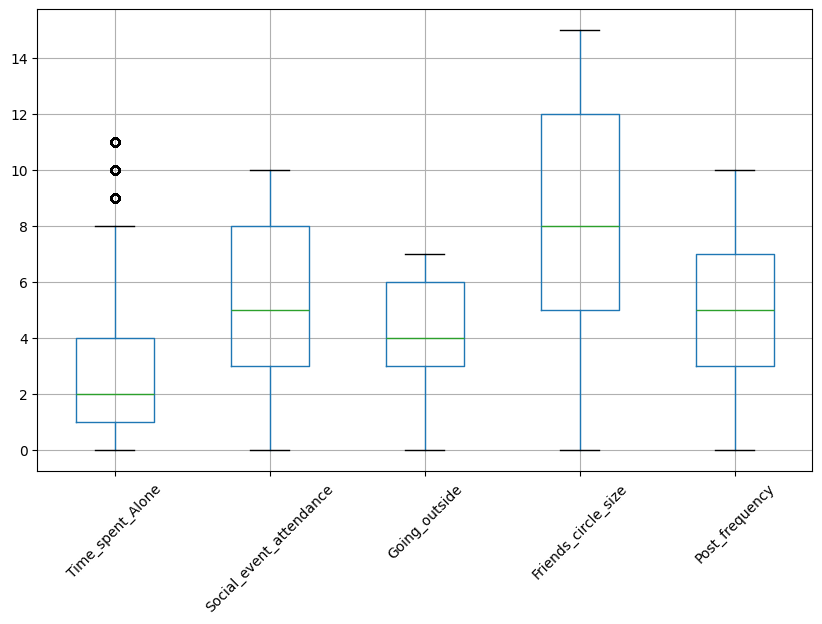

In [8]:
train.select_dtypes(include=np.number).boxplot(figsize=(10,6))
plt.xticks(rotation=45)
plt.show()

### Strategija A: uklanjanje outliera (IQR)

Ova funkcija uklanja redove koji sadrže ekstremne vrednosti koristeći IQR metodu.

Koraci:

Računa se prvi kvartil (Q1)
Računa se treći kvartil (Q3)
Izračunava se:

IQR=Q3−Q1

Sve vrednosti van intervala:

[Q1−1.5⋅IQR, Q3+1.5⋅IQR]

smatraju se outlierima i uklanjaju se.

Prednost:

dataset postaje stabilniji.

Mana:

može doći do gubitka velikog broja podataka.

In [9]:
def remove_outliers(df):
    df_out = df.copy()
    num_cols = df_out.select_dtypes(include=np.number).columns
    
    for col in num_cols:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        
        df_out = df_out[(df_out[col] >= Q1 - 1.5*IQR) & (df_out[col] <= Q3 + 1.5*IQR)]
    
    return df_out

train_no_outliers = remove_outliers(train_dropna)

### Strategija B: clipping

Umesto uklanjanja redova, clipping metoda ograničava ekstremne vrednosti na dozvoljene granice.

Ako je neka vrednost:

- manja od donje granice → postavlja se na donju granicu
- veća od gornje granice → postavlja se na gornju granicu

Prednost:

- čuvaju se svi redovi podataka,
- smanjuje se negativan uticaj ekstremnih vrednosti.

Ova metoda je često korisna kada dataset nije veliki.

In [10]:
def clip_outliers(df):
    df_clip = df.copy()
    num_cols = df_clip.select_dtypes(include=np.number).columns
    
    for col in num_cols:
        Q1 = df_clip[col].quantile(0.25)
        Q3 = df_clip[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5*IQR
        upper = Q3 + 1.5*IQR
        
        df_clip[col] = df_clip[col].clip(lower, upper)
    
    return df_clip

train_clipped = clip_outliers(train_fillna)

### 2.4 Balansiranost klasa

Ovaj grafikon prikazuje broj uzoraka za svaku klasu ciljne promenljive Personality.

Balansiran dataset znači da klase imaju približno isti broj primera.

Ako je jedna klasa mnogo zastupljenija od druge, model može postati pristrasan i favorizovati dominantnu klasu.

Kod nebalansiranih podataka često se koriste:

- oversampling,
- undersampling,
- class weights.

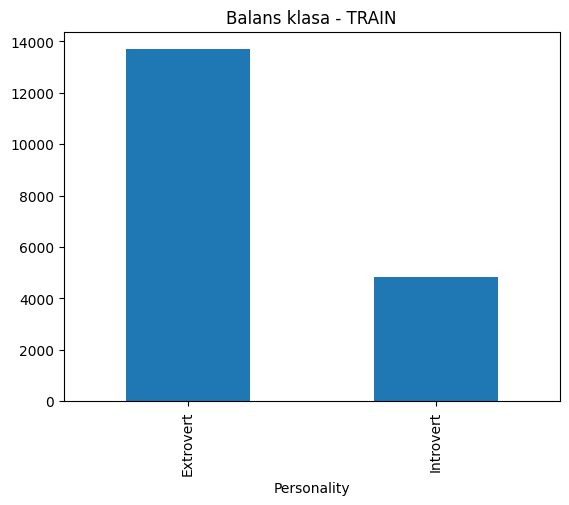

In [11]:
train["Personality"].value_counts().plot(kind="bar")
plt.title("Balans klasa - TRAIN")
plt.show()

### 2.5 Statistika + histogrami

Funkcija describe() prikazuje osnovne statističke informacije:

- prosečnu vrednost,
- standardnu devijaciju,
- minimalne i maksimalne vrednosti,
- kvartile.

Histogrami prikazuju raspodelu podataka u kolonama i pomažu u otkrivanju:

- asimetrije,
- outliera,
- normalne raspodele,
- koncentracije vrednosti.

In [12]:
train.describe()

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,17334.000000,17344.000000,17058.000000,17470.000000,17260.000000
mean,3.137764,5.265106,4.044319,7.996737,4.982097
std,3.003786,2.753359,2.062580,4.223484,2.879139
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,3.000000,3.000000,5.000000,3.000000
50%,2.000000,5.000000,4.000000,8.000000,5.000000
75%,4.000000,8.000000,6.000000,12.000000,7.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


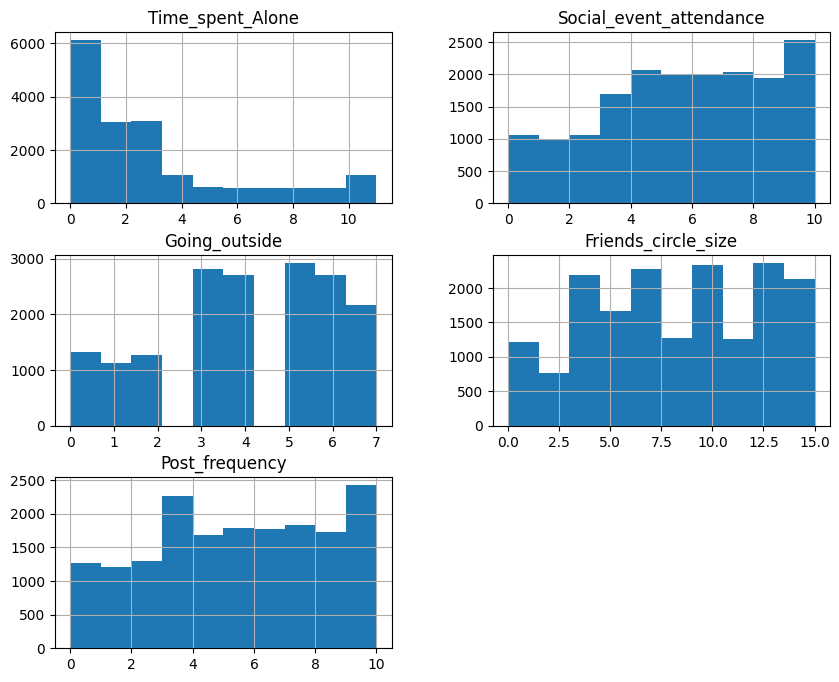

In [13]:
train.hist(figsize=(10,8))
plt.show()

## 3. Treniranje modela (Decision Tree)

### Enkodiranje kategorija

U ovom delu projekta pripremaju se podaci za treniranje Machine Learning modela.
Koriste se biblioteke za:

- podelu podataka na trening i test skup,
- enkodiranje kategorijskih podataka,
- pravljenje preprocessing pipeline-a.

Pipeline omogućava povezivanje svih koraka obrade i modela u jednu celinu, dok ColumnTransformer omogućava različitu obradu numeričkih i kategorijskih kolona.

OneHotEncoder pretvara tekstualne kategorije u numerički oblik koji modeli mogu da koriste.

Dataset se deli na:

- ulazne podatke (X)
- ciljnu promenljivu (y)

Kolona Personality predstavlja ciljnu klasu koju model pokušava da predvidi.

Podaci se dele na:

- trening skup (80%)
- test skup (20%)

Trening skup koristi se za učenje modela, dok test skup služi za proveru koliko model dobro generalizuje na novim podacima.

Parametar:

- test_size=0.2

znači da 20% podataka ide za testiranje.

random_state=42 omogućava da se svaki put dobije ista podela podataka.

Grafici prikazuju raspodelu klasa u trening i test skupu.

Važno je da obe grupe imaju približno sličnu raspodelu klasa kako model ne bi bio pristrasan prema jednoj kategoriji.

Ako su klase previše nebalansirane:

- model može favorizovati dominantnu klasu,
- accuracy može izgledati dobro iako model loše radi.

Ovim kodom pronalaze se sve kategorijske kolone, odnosno kolone koje nisu numeričkog tipa.

Te kolone je potrebno enkodirati pre treniranja modela.

OneHotEncoder pretvara kategorijske vrednosti u binarne kolone.

handle_unknown="ignore" omogućava ignorisanje novih kategorija koje se pojave u test podacima.

try/except je dodat zbog kompatibilnosti različitih verzija biblioteke scikit-learn.

ColumnTransformer primenjuje:

OneHotEncoding samo nad kategorijskim kolonama,
dok numeričke kolone ostavlja nepromenjene (passthrough).

Na ovaj način dataset postaje potpuno numerički i spreman za Machine Learning model.

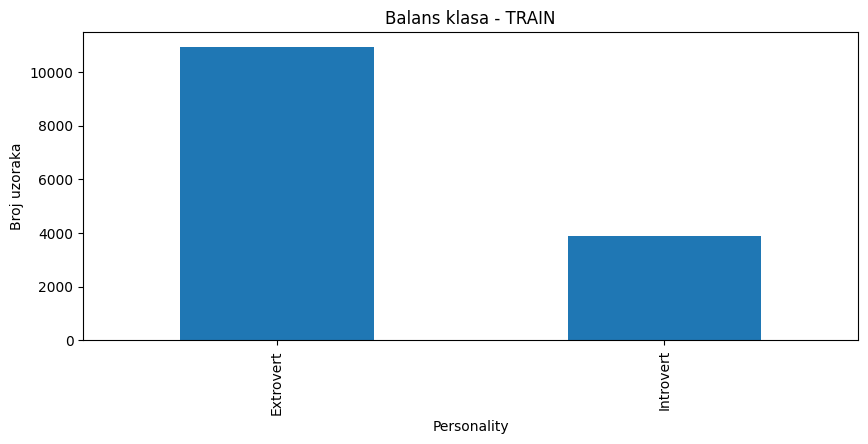

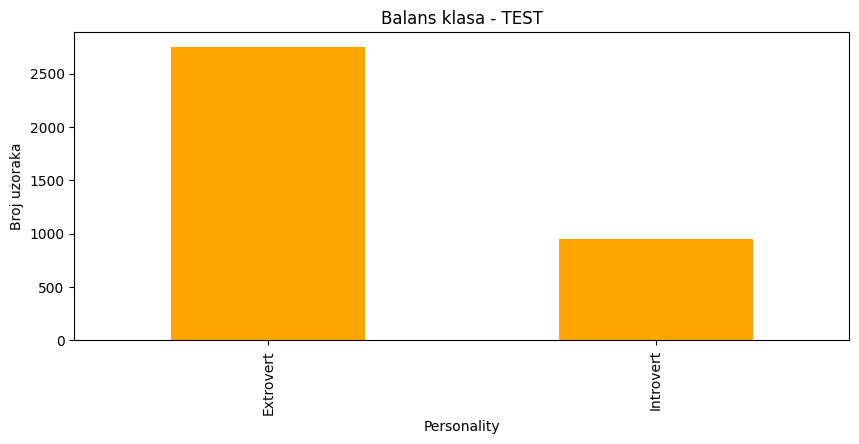

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# koristimo dataset sa popunjenim NaN vrednostima
X = train_fillna.drop("Personality", axis=1)
y = train_fillna["Personality"]

# split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# balans klasa u trening i test skupu
plt.figure(figsize=(10,4))
y_train.value_counts().plot(kind="bar")
plt.title("Balans klasa - TRAIN")
plt.xlabel("Personality")
plt.ylabel("Broj uzoraka")
plt.show()

plt.figure(figsize=(10,4))
y_test.value_counts().plot(kind="bar", color="orange")
plt.title("Balans klasa - TEST")
plt.xlabel("Personality")
plt.ylabel("Broj uzoraka")
plt.show()

cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            ohe,
            cat_cols,
        )
    ],
    remainder="passthrough",
)


### 3.1 GridSearch + trening

<b>Decision Tree</b> je algoritam koji donosi odluke grananjem uslova.

Model pravi strukturu nalik stablu:

- svaki čvor predstavlja uslov, 
- grane predstavljaju odluke,
- listovi predstavljaju konačne klase.

<span style="color: royalblue">Prednosti:</span>

jednostavan za interpretaciju,
radi i sa numeričkim i sa kategorijskim podacima,
lako se vizualizuje.

<span style="color: red">Mana:</span>

lako dolazi do overfitting-a.

<b>Pipeline povezuje:</b>

1. preprocessing
2. model

Prednost pipeline-a:

- preprocessing se automatski primenjuje i na trening i na test podatke,
- smanjuje mogućnost greške,
- olakšava GridSearch.

<b>Grid Search</b> automatski testira različite kombinacije hiperparametara kako bi pronašao najbolji model.

Testiraju se:

- kriterijum grananja,
- maksimalna dubina stabla,
- minimalan broj uzoraka za grananje,
- minimalan broj uzoraka u listu.

<b>Max depth</b>

<i>max_depth</i>

Predstavlja maksimalnu dubinu stabla.

- mala dubina → model može biti previše jednostavan
- velika dubina → moguć overfitting

<b>Min samples split</b>

<i>min_samples_split</i>

Minimalan broj uzoraka potreban da bi se čvor dalje delio.

<b>Min samples leaf</b>

<i>min_samples_leaf</i>

Minimalan broj uzoraka koji mora postojati u listu stabla.

<b>GridSearchCV</b> koristi cross-validation kako bi pronašao najbolju kombinaciju parametara.

cv=5

znači da se podaci dele na 5 delova:

- 4 dela za trening
- 1 deo za validaciju

Proces se ponavlja 5 puta.

<b>Treniranje modela</b>

Model uči obrasce iz trening podataka i testira različite kombinacije hiperparametara.

Na kraju se bira model sa najboljim accuracy rezultatom.

<b>Najbolji model</b>
<i>best_estimator_</i> vraća najbolje istreniran model pronađen tokom Grid Search procesa.

In [15]:
# model
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("clf", DecisionTreeClassifier(random_state=42)),
    ]
)

# parametri za Grid Search
param_grid = {
    "clf__criterion": ["gini", "entropy", "log_loss"],
    "clf__max_depth": [3, 5, 10, None],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4]
}

# Grid Search
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

# treniranje modela
grid.fit(X_train, y_train)

# najbolji model
print("Najbolji parametri:", grid.best_params_)

best_model = grid.best_estimator_


Najbolji parametri: {'clf__criterion': 'gini', 'clf__max_depth': 5, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 10}


### 3.1b Vizualizacija stabla

Funkcija <i>plot_tree()</i> koristi se za grafički prikaz Decision Tree modela.

Na stablu se mogu videti:

- uslovi grananja,
- broj uzoraka,
- klase,
- odluke modela.

Vizualizacija omogućava bolje razumevanje načina rada modela.

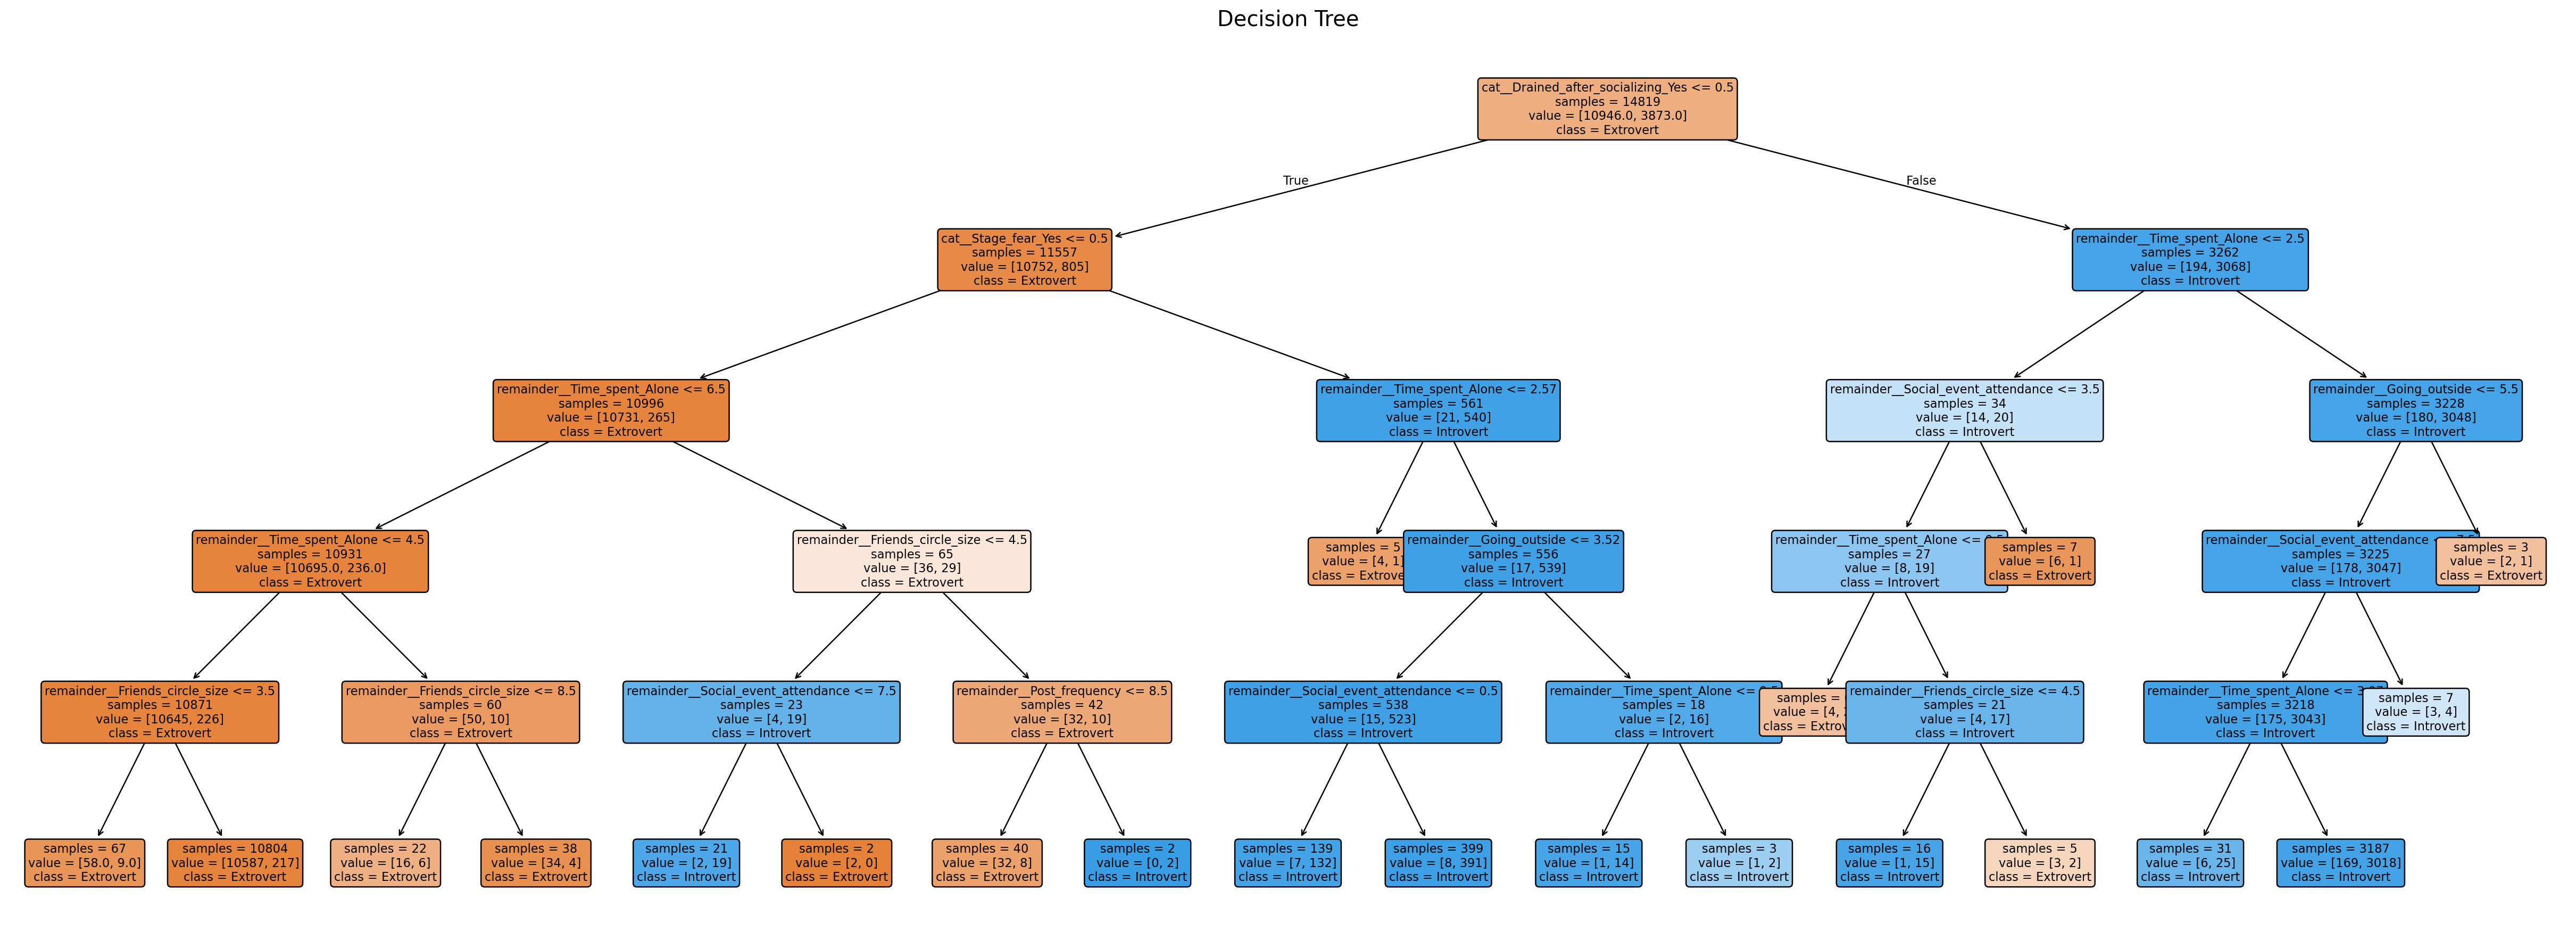

In [16]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# lepši i pregledniji prikaz stabla
fig, ax = plt.subplots(figsize=(27, 10), dpi=180)

plot_tree(
    best_model.named_steps["clf"],
    feature_names=best_model.named_steps["preprocessor"].get_feature_names_out(),
    class_names=[str(c) for c in best_model.named_steps["clf"].classes_],
    filled=True,
    rounded=True,
    fontsize=9,
    precision=2,
    proportion=False,
    impurity=False,
    ax=ax
)

ax.set_title("Decision Tree", fontsize=16)

plt.tight_layout()
plt.show()

plt.close()

### 3.1c + 4 Evaluacija

Evaluacija meri uspešnost modela pomoću različitih metrika.

Koriste se:

- confusion matrix,
- accuracy,
- precision,
- recall,
- F1 score,
- classification report.

<b><i>Accuracy</b></i> = (TP+TN+FP+FN)/(TP+TN)
	

- Predstavlja procenat tačnih predikcija.

<b><i>Recall</b></i> = TP/(TP+FN)

- Meri koliko stvarno pozitivnih primera je pronadjeno

<b><i>F1</b></i> = 2* Precision * Recall/(Precision+Recall)

- Predstavlja balans izmedju precision i recall metrike

In [17]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

def evaluate(model, X, y, name):
    y_pred = model.predict(X)

    print(f"--- {name} ---")
    print("Confusion matrix:\n", confusion_matrix(y, y_pred))
    print("Accuracy:", accuracy_score(y, y_pred))
    print("Precision:", precision_score(y, y_pred, average="weighted"))
    print("Recall:", recall_score(y, y_pred, average="weighted"))
    print("F1:", f1_score(y, y_pred, average="weighted"))

    print("\nClassification report:\n")
    print(classification_report(y, y_pred))

In [18]:
evaluate(best_model, X_train, y_train, "TRAIN")
evaluate(best_model, X_test, y_test, "TEST")

--- TRAIN ---
Confusion matrix:
 [[10748   198]
 [  251  3622]]
Accuracy: 0.9697010594507052
Precision: 0.9695972976023793
Recall: 0.9697010594507052
F1: 0.9696332769147724

Classification report:

              precision    recall  f1-score   support

   Extrovert       0.98      0.98      0.98     10946
   Introvert       0.95      0.94      0.94      3873

    accuracy                           0.97     14819
   macro avg       0.96      0.96      0.96     14819
weighted avg       0.97      0.97      0.97     14819

--- TEST ---
Confusion matrix:
 [[2703   50]
 [  74  878]]
Accuracy: 0.9665317139001349
Precision: 0.9663553132584788
Recall: 0.9665317139001349
F1: 0.9663907121176742

Classification report:

              precision    recall  f1-score   support

   Extrovert       0.97      0.98      0.98      2753
   Introvert       0.95      0.92      0.93       952

    accuracy                           0.97      3705
   macro avg       0.96      0.95      0.96      3705
weighted a

### 3.1.d Overfitting

Overfitting nastaje kada model previše nauči trening podatke i loše radi na novim podacima.

Ako je:

<i> TrainAccuracy − TestAccuracy > 0.1 </i>

moguće je da postoji overfitting.

Cilj je da trening i test accuracy budu što sličniji.

In [19]:
train_acc = accuracy_score(y_train, best_model.predict(X_train))
test_acc = accuracy_score(y_test, best_model.predict(X_test))

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)

if train_acc - test_acc > 0.1:
    print("Moguci overfitting.")
else:
    print("Nema znacajnog overfitting-a.")

Train accuracy: 0.9697010594507052
Test accuracy: 0.9665317139001349
Nema znacajnog overfitting-a.


### 3.1e Feature importance

Feature importance prikazuje koliko je svaka kolona važna za donošenje odluka modela.

Veće vrednosti znače da određena karakteristika ima veći uticaj na predikciju.

Ova analiza pomaže:

- razumevanju modela,
- uklanjanju nebitnih kolona,
- Feature Engineering procesu.

### Decision Tree feature importances


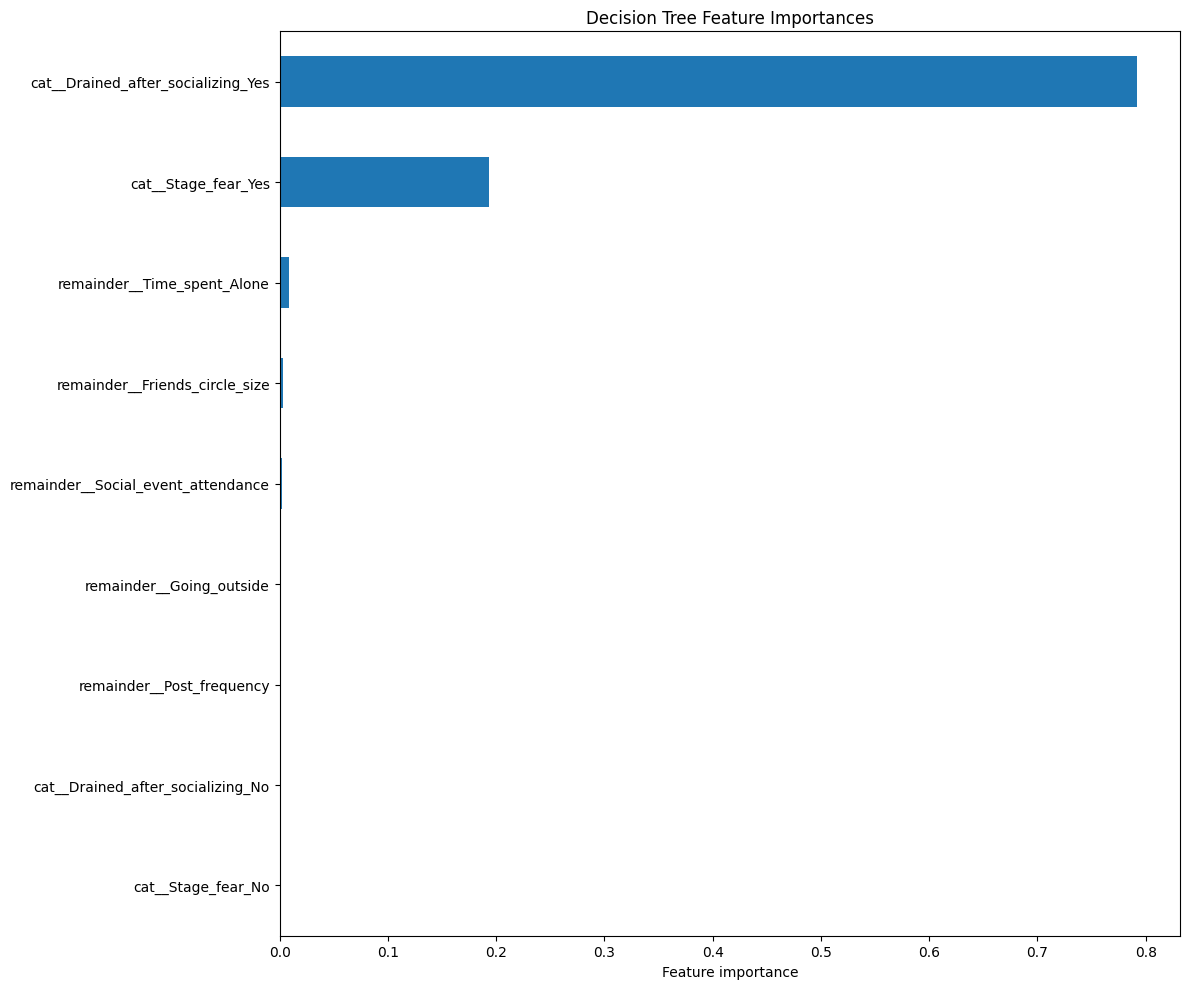


### ExtraTrees feature importances


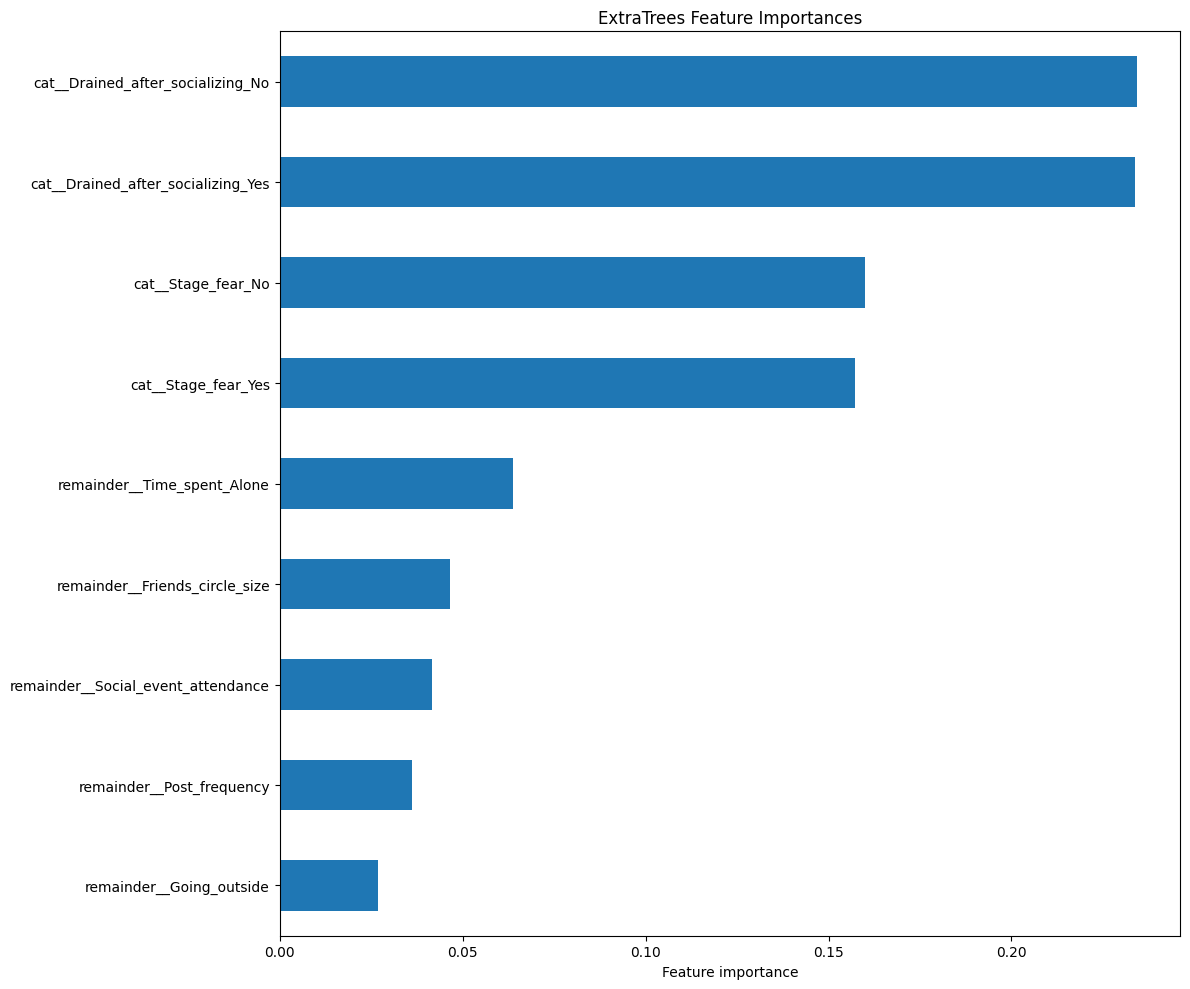


Top 10 Decision Tree features:
cat__Stage_fear_No                    0.000000
cat__Drained_after_socializing_No     0.000000
remainder__Post_frequency             0.000500
remainder__Going_outside              0.000510
remainder__Social_event_attendance    0.001772
remainder__Friends_circle_size        0.003079
remainder__Time_spent_Alone           0.009015
cat__Stage_fear_Yes                   0.193003
cat__Drained_after_socializing_Yes    0.792122
dtype: float64

Top 10 ExtraTrees features:
remainder__Going_outside              0.026893
remainder__Post_frequency             0.036068
remainder__Social_event_attendance    0.041561
remainder__Friends_circle_size        0.046583
remainder__Time_spent_Alone           0.063757
cat__Stage_fear_Yes                   0.157186
cat__Stage_fear_No                    0.159885
cat__Drained_after_socializing_Yes    0.233737
cat__Drained_after_socializing_No     0.234330
dtype: float64


In [20]:
from sklearn.ensemble import ExtraTreesClassifier
from IPython.display import display, Markdown

# Train an ExtraTrees model on the same split used for the Decision Tree
extra = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("clf", ExtraTreesClassifier(random_state=42)),
    ]
)
extra.fit(X_train, y_train)


def plot_importances(model, title):
    importances = model.named_steps["clf"].feature_importances_
    feature_names = model.named_steps["preprocessor"].get_feature_names_out()
    imp_df = pd.Series(importances, index=feature_names).sort_values(ascending=True)

    plt.figure(figsize=(12, 10))
    imp_df.plot(kind="barh")
    plt.title(title)
    plt.xlabel("Feature importance")
    plt.tight_layout()
    plt.show()

    return imp_df

print("### Decision Tree feature importances")
dt_importances = plot_importances(best_model, "Decision Tree Feature Importances")
print("\n### ExtraTrees feature importances")
extra_importances = plot_importances(extra, "ExtraTrees Feature Importances")

print("\nTop 10 Decision Tree features:")
print(dt_importances.tail(10))
print("\nTop 10 ExtraTrees features:")
print(extra_importances.tail(10))

### 3.1f ExtraTreesClassifier

<i>ExtraTreesClassifier</i> je ansambl metoda zasnovana na većem broju stabala odlučivanja.

Razlika u odnosu na običan Decision Tree:

- koristi više stabala,
- uvodi dodatnu slučajnost,
- često daje stabilnije rezultate i manji overfitting.

Zbog toga se često koristi za:

- feature importance,
- poređenje performansi modela.

In [21]:
# Evaluate the ExtraTrees model trained above
evaluate(extra, X_test, y_test, "ExtraTrees TEST")

--- ExtraTrees TEST ---
Confusion matrix:
 [[2700   53]
 [  75  877]]
Accuracy: 0.9654520917678813
Precision: 0.9652741784490511
Recall: 0.9654520917678813
F1: 0.965318910405454

Classification report:

              precision    recall  f1-score   support

   Extrovert       0.97      0.98      0.98      2753
   Introvert       0.94      0.92      0.93       952

    accuracy                           0.97      3705
   macro avg       0.96      0.95      0.95      3705
weighted avg       0.97      0.97      0.97      3705



## 4. Eksperimenti sa različitim verzijama podataka

U ovoj sekciji testiraju se različite strategije za obradu podataka kako bi se pronašla kombinacija koja daje najbolje rezultate modela.

Testiraju se četiri različite verzije dataseta:

1. <i> dropna + remove outliers</i>
- uklanjaju se NaN vrednosti
- uklanjaju se outlieri
2. <i> dropna + clip outliers</i>
- uklanjaju se NaN vrednosti
- outlieri se ograničavaju (clipping)
3. <i> fillna + remove outliers</i>
- NaN vrednosti se popunjavaju
- outlieri se uklanjaju
4. <i> fillna + clip outliers</i>
- NaN vrednosti se popunjavaju
- outlieri se ograničavaju

Cilj eksperimenta je pronalaženje najbolje strategije preprocessing-a za dalje treniranje modela.

### 4.1 Kreiranje različitih verzija dataseta

In [22]:
# 1. dropna + remove outliers
data_1 = remove_outliers(train.dropna())

# 2. dropna + clip outliers
data_2 = clip_outliers(train.dropna())

# 3. fillna + remove outliers
data_3 = remove_outliers(train_fillna)

# 4. fillna + clip outliers
data_4 = clip_outliers(train_fillna)

### 4.2 Pokretanje eksperimenata

Za svaku verziju dataseta:

- podaci se dele na trening i test skup,
- kategorijske kolone se enkodiraju,
- trenira se Decision Tree model,
- meri se accuracy.

Na ovaj način moguće je uporediti kako različite metode preprocessing-a utiču na performanse modela.

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [24]:
def run_experiment(data, name):

    # X i y
    X = data.drop("Personality", axis=1)
    y = data["Personality"]

    # split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    # kategorijske kolone
    cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

    # OneHotEncoder
    try:
        ohe = OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    except TypeError:
        ohe = OneHotEncoder(
            handle_unknown="ignore",
            sparse=False
        )

    # preprocessing
    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", ohe, cat_cols)
        ],
        remainder="passthrough"
    )

    # pipeline
    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("clf", DecisionTreeClassifier(random_state=42))
        ]
    )

    # treniranje
    model.fit(X_train, y_train)

    # predikcija
    y_pred = model.predict(X_test)

    # accuracy
    acc = accuracy_score(y_test, y_pred)

    print(name)
    print("Accuracy:", round(acc, 4))
    print()

In [25]:
run_experiment(data_1, "dropna + remove outliers")

run_experiment(data_2, "dropna + clip outliers")

run_experiment(data_3, "fillna + remove outliers")

run_experiment(data_4, "fillna + clip outliers")

dropna + remove outliers
Accuracy: 0.9368

dropna + clip outliers
Accuracy: 0.921

fillna + remove outliers
Accuracy: 0.9428

fillna + clip outliers
Accuracy: 0.926



###  4.3 Analiza rezultata eksperimenata

Rezultati eksperimenata omogućavaju poređenje različitih preprocessing strategija.

U praksi:

- potpuno uklanjanje redova (dropna) može smanjiti količinu podataka,
- popunjavanje NaN vrednosti (fillna) često daje bolje rezultate,
- clipping outliera može biti stabilniji od njihovog uklanjanja.

Na osnovu accuracy rezultata bira se najbolja verzija dataseta za dalje eksperimente.

U ovom projektu kao najbolja verzija izabran je:

fillna + remove outliers

jer daje najbolje ili najstabilnije rezultate.

### 4.4 Izbor najboljeg dataseta

In [26]:
# najbolja verzija dataseta
data_best = data_2

# X i y
X = data_best.drop("Personality", axis=1)
y = data_best["Personality"]

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

## 5. Uporedjivanje modela

U ovoj sekciji porede se performanse:

- Decision Tree modela
- ExtraTrees modela

Koriste se sledeće metrike:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

Cilj je utvrditi koji model daje bolje rezultate nad test skupom.

### 5.1 Import biblioteka

In [27]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

### 5.2 Preprocessing

In [28]:
# kategorijske kolone
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

# encoder
try:
    ohe = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    ohe = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

# preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", ohe, cat_cols)
    ],
    remainder="passthrough"
)

### 5.3 Kreiranje modela

In [29]:
# Decision Tree
pipeline_dt = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("clf", DecisionTreeClassifier(random_state=42))
    ]
)

# ExtraTrees
pipeline_extra = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("clf", ExtraTreesClassifier(random_state=42))
    ]
)

### 5.4 Treniranje modela

In [30]:
pipeline_dt.fit(X_train, y_train)

pipeline_extra.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

### 5.5 Evaluacija modela

In [31]:
models = {
    "Decision Tree": pipeline_dt,
    "ExtraTrees": pipeline_extra,
}

for name, model in models.items():

    y_pred = model.predict(X_test)

    print(name)
 

    print(
        "Accuracy:",
        round(accuracy_score(y_test, y_pred), 4)
    )

    print(
        "Precision:",
        round(
            precision_score(
                y_test,
                y_pred,
                average="weighted"
            ),
            4
        )
    )

    print(
        "Recall:",
        round(
            recall_score(
                y_test,
                y_pred,
                average="weighted"
            ),
            4
        )
    )

    print(
        "F1-score:",
        round(
            f1_score(
                y_test,
                y_pred,
                average="weighted"
            ),
            4
        )
    )

    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, y_pred))

    print()

Decision Tree
Accuracy: 0.9279
Precision: 0.9283
Recall: 0.9279
F1-score: 0.9281

Confusion matrix:
[[1609   76]
 [  71  282]]

ExtraTrees
Accuracy: 0.9598
Precision: 0.9591
Recall: 0.9598
F1-score: 0.959

Confusion matrix:
[[1660   25]
 [  57  296]]



## 6. Feature Engineering

Feature Engineering predstavlja proces kreiranja novih karakteristika (feature-a) ili transformacije postojećih kolona kako bi model bolje prepoznao obrasce u podacima.

U mašinskom učenju kvalitet podataka često ima veći uticaj na performanse modela nego sam izbor algoritma. Zbog toga je pravilna obrada i kreiranje feature-a veoma važan deo svakog ML projekta.

Najčešće tehnike Feature Engineering-a uključuju:

- enkodiranje kategorijskih podataka,
- skaliranje i normalizaciju,
- kreiranje novih kolona iz postojećih,
- uklanjanje redundantnih ili nebitnih kolona,
- selekciju najvažnijih karakteristika,
- smanjenje dimenzionalnosti.

Model nekada može raditi bolje sa manjim brojem kolona jer:

- neke kolone predstavljaju šum,
- neke kolone nose veoma malo korisnih informacija,
- neke kolone su međusobno veoma korelisane,
- veliki broj nebitnih kolona može izazvati overfitting.

Poželjno je uklanjati:

- redundantne kolone,
- veoma korelisane kolone,
- kolone sa mnogo šuma,
- kolone koje imaju veoma mali uticaj na predikciju.

Cilj Feature Engineering-a je:

- povećanje tačnosti modela,
- bolje generalizovanje modela,
- smanjenje overfitting-a,
- jednostavnije i efikasnije modele.

### 6.1 Kreiranje novih kolona

U ovoj sekciji kreiraju se nove karakteristike na osnovu postojećih podataka.

Nove kolone omogućavaju modelu da lakše uoči odnose između različitih osobina korisnika.

Kreirane su sledeće kolone:

1. isolation_score
<i>Time_spent_Alone / (Going_outside + 1)</i>

Ova kolona predstavlja odnos vremena provedenog u samoći i učestalosti izlazaka.

Veća vrednost može ukazivati na:

- veću izolovanost,
- manju društvenu aktivnost.

U imenilac se dodaje +1 kako bi se izbeglo deljenje nulom u slučajevima kada osoba nikada ne izlazi.

2. social_score
<i>Social_event_attendance * Friends_circle_size</i>

Ova kolona predstavlja kombinovanu meru društvene aktivnosti.

Korisnici koji:

- često posećuju društvene događaje,
- imaju veliki krug prijatelja,

imaće veću vrednost ove karakteristike.

3. digital_vs_real
<i>Post_frequency / (Social_event_attendance + 1)</i>

Ova kolona predstavlja odnos online i offline društvene aktivnosti.

Veće vrednosti mogu ukazivati na:

- veću aktivnost na društvenim mrežama,
- manju aktivnost u realnim društvenim događajima.

I ovde se dodaje +1 kako bi se izbeglo deljenje nulom.

Cilj kreiranja novih kolona je da model dobije dodatne informacije koje možda nisu direktno vidljive iz originalnih podataka.

In [32]:
def add_engineered_features(df):

    df = df.copy()

    # odnos izolacije i izlazaka
    # +1 se dodaje kako bi se izbeglo deljenje nulom
    df["isolation_score"] = (
        df["Time_spent_Alone"] /
        (df["Going_outside"] + 1)
    )

    # društvena aktivnost
    df["social_score"] = (
        df["Social_event_attendance"] *
        df["Friends_circle_size"]
    )

    # online vs offline aktivnost
    # +1 se dodaje kako bi se izbeglo deljenje nulom
    df["digital_vs_real"] = (
        df["Post_frequency"] /
        (df["Social_event_attendance"] + 1)
    )

    return df

### 6.2 Treniranje modela sa novim kolonama

Nakon kreiranja novih karakteristika modeli se ponovo treniraju kako bi se proverilo da li dodatni feature-i poboljšavaju performanse modela.

Ponovo se treniraju:

- Decision Tree model,
- ExtraTrees model.

Rezultati modela sa novim kolonama porede se sa prethodnim modelima koji nisu koristili Feature Engineering.

Koriste se iste metrike:

- Accuracy,
- Precision,
- Recall,
- F1-score.

Na ovaj način moguće je proveriti:

- da li nove kolone donose korisne informacije,
- da li poboljšavaju generalizaciju modela,
- da li povećavaju tačnost predikcije.

Ukoliko rezultati postanu bolji nakon dodavanja novih kolona, može se zaključiti da Feature Engineering uspešno poboljšava model.

In [33]:
# kategorijske kolone
# kategorijske kolone
# kreiranje feature-engineered varijabli
X_train_fe = add_engineered_features(X_train)
X_test_fe = add_engineered_features(X_test)

cat_cols_fe = (
    X_train_fe
    .select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

# preprocessing
preprocessor_fe = ColumnTransformer(
    transformers=[
        ("cat", ohe, cat_cols_fe)
    ],
    remainder="passthrough"
)

In [34]:

# Decision Tree
pipeline_fe_dt = Pipeline(
    steps=[
        ("preprocessor", preprocessor_fe),
        ("clf", DecisionTreeClassifier(random_state=42))
    ]
)

# ExtraTrees
pipeline_fe_extra = Pipeline(
    steps=[
        ("preprocessor", preprocessor_fe),
        ("clf", ExtraTreesClassifier(random_state=42))
    ]
)

In [35]:
# treniranje
pipeline_fe_dt.fit(X_train_fe, y_train)

pipeline_fe_extra.fit(X_train_fe, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

### 6.3 Funkcija za evaluaciju

U mašinskom učenju je važno da se modeli ne ocenjuju samo jednom metrikom (npr. accuracy), već da se koristi više različitih mera kako bi se dobila realnija slika performansi modela.

Zbog toga se definiše funkcija za evaluaciju koja automatski računa sve važne metrike.

Šta ova funkcija radi?

Funkcija:

- pravi predikcije na osnovu modela,
- upoređuje ih sa stvarnim vrednostima,
- računa više evaluacionih metrika,
- vraća rezultate u obliku rečnika (dictionary).

Metrike koje se koriste:
- Accuracy → koliko je ukupno predikcija tačno
- Precision → koliko su pozitivne predikcije zaista tačne
- Recall → koliko stvarnih pozitivnih slučajeva je model pronašao
- F1-score → balans između precision i recall

Svi rezultati se računaju sa weighted average zbog mogućeg disbalansa klasa.

In [36]:
def compute_metrics(model, X, y):

    y_pred = model.predict(X)

    return {
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(
            y,
            y_pred,
            average="weighted"
        ),
        "recall": recall_score(
            y,
            y_pred,
            average="weighted"
        ),
        "f1": f1_score(
            y,
            y_pred,
            average="weighted"
        )
    }

In [37]:
# rezultati osnovnih modela
baseline_dt = compute_metrics(
    pipeline_dt,
    X_test,
    y_test
)

baseline_extra = compute_metrics(
    pipeline_extra,
    X_test,
    y_test
)

# rezultati modela sa feature engineering-om
fe_dt = compute_metrics(
    pipeline_fe_dt,
    X_test_fe,
    y_test
)

fe_extra = compute_metrics(
    pipeline_fe_extra,
    X_test_fe,
    y_test
)

In [38]:
# prikaz rezultata

print("Decision Tree - osnovni model")
print(baseline_dt)

print("\nExtraTrees - osnovni model")
print(baseline_extra)

print("\nDecision Tree - Feature Engineering")
print(fe_dt)

print("\nExtraTrees - Feature Engineering")
print(fe_extra)


Decision Tree - osnovni model
{'accuracy': 0.9278704612365064, 'precision': 0.9282876069627857, 'recall': 0.9278704612365064, 'f1': 0.9280704932069208}

ExtraTrees - osnovni model
{'accuracy': 0.9597644749754661, 'precision': 0.9590628587627572, 'recall': 0.9597644749754661, 'f1': 0.9589985613148551}

Decision Tree - Feature Engineering
{'accuracy': 0.9337585868498528, 'precision': 0.9334019590509024, 'recall': 0.9337585868498528, 'f1': 0.9335714155720343}

ExtraTrees - Feature Engineering
{'accuracy': 0.9602551521099116, 'precision': 0.9595705705169374, 'recall': 0.9602551521099116, 'f1': 0.9595236291121442}


### 6.4 Feature importance

Feature Importance predstavlja meru važnosti svake kolone za donošenje odluka modela.

Kolone sa većom importance vrednošću imaju veći uticaj na predikciju modela.

Za analizu feature importance korišćeni su:

- Decision Tree,
- ExtraTreesClassifier.

Prikaz feature importance omogućava:

- razumevanje rada modela,
- identifikaciju najvažnijih karakteristika,
- pronalaženje nebitnih ili redundantnih kolona.

Rezultati su prikazani pomoću horizontalnih bar grafikona.

Kolone koje imaju veoma malu importance vrednost:

- mogu predstavljati šum,
- mogu biti kandidati za uklanjanje,
- često imaju mali uticaj na performanse modela.

Posebno je korisno uporediti:

- importance originalnih kolona,
- importance novih feature-a.

Na taj način može se proveriti da li Feature Engineering zaista doprinosi modelu.

Ako novokreirane kolone imaju visoku importance vrednost, to znači da su uspešno dodale korisne informacije modelu.

In [39]:
def get_feature_importance_df(model):

    importances = (
        model.named_steps["clf"]
        .feature_importances_
    )

    feature_names = (
        model.named_steps["preprocessor"]
        .get_feature_names_out()
    )

    return pd.Series(
        importances,
        index=feature_names
    ).sort_values(ascending=False)

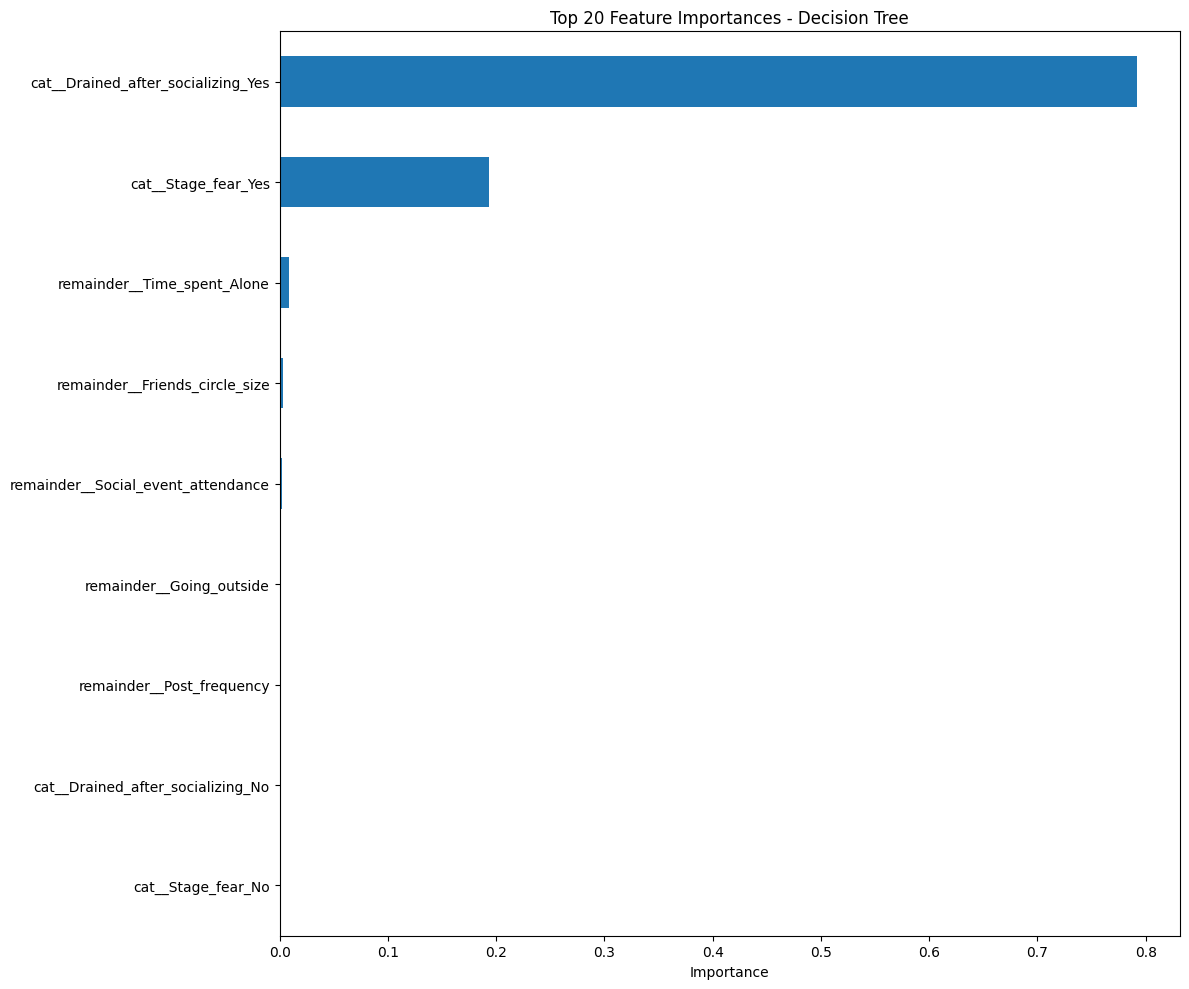

In [40]:
# Decision Tree importance
plt.figure(figsize=(12, 10))

dt_importances.head(20).sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 20 Feature Importances - Decision Tree"
)

plt.xlabel("Importance")

plt.tight_layout()
plt.show()

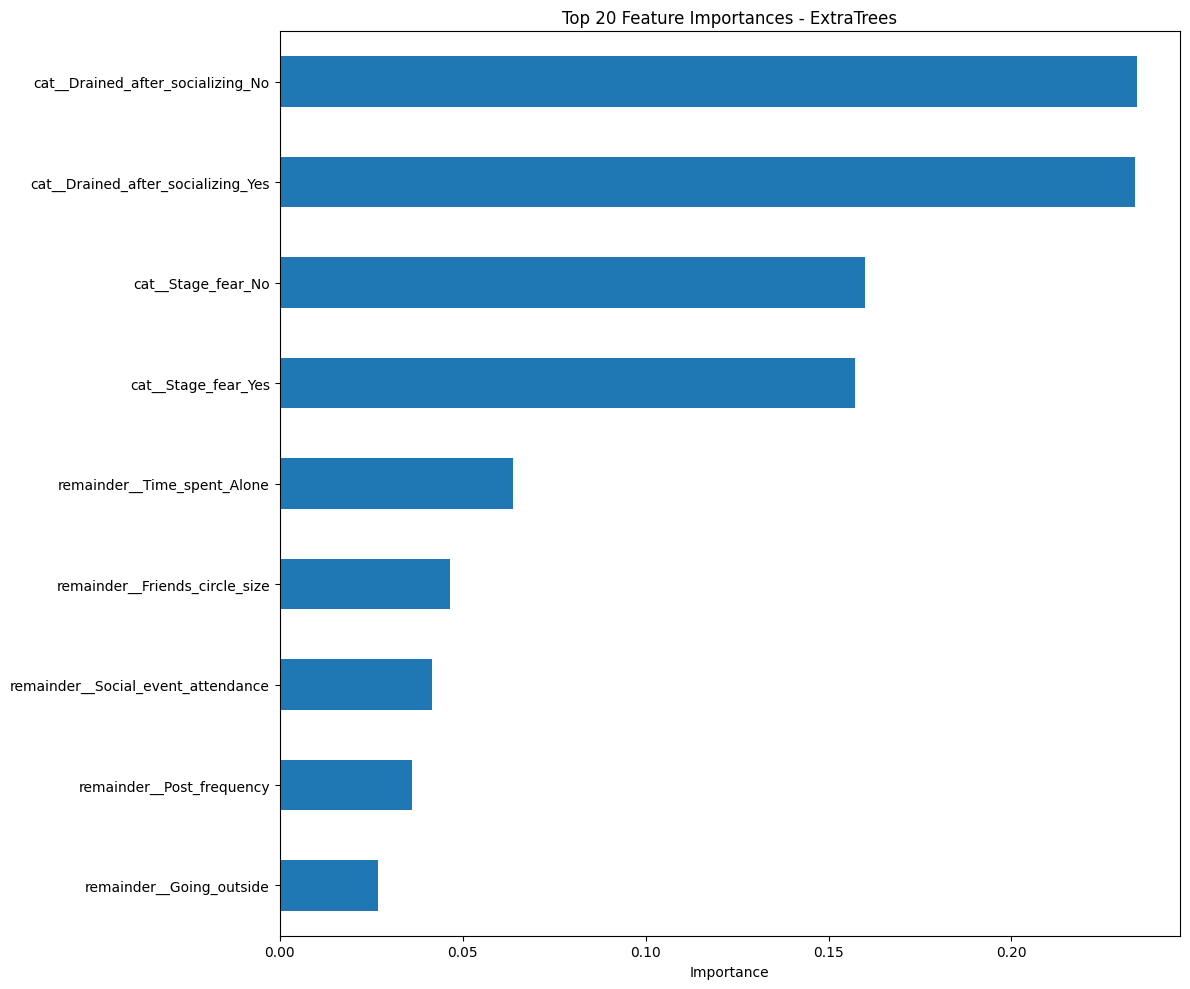

In [41]:
# ExtraTrees importance
plt.figure(figsize=(12, 10))

extra_importances.head(20).sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 20 Feature Importances - ExtraTrees"
)

plt.xlabel("Importance")

plt.tight_layout()
plt.show()

In [42]:
print("Top 10 Decision Tree feature importances")
print(dt_importances.head(10))

print("\nTop 10 ExtraTrees feature importances")
print(extra_importances.head(10))

Top 10 Decision Tree feature importances
cat__Stage_fear_No                    0.000000
cat__Drained_after_socializing_No     0.000000
remainder__Post_frequency             0.000500
remainder__Going_outside              0.000510
remainder__Social_event_attendance    0.001772
remainder__Friends_circle_size        0.003079
remainder__Time_spent_Alone           0.009015
cat__Stage_fear_Yes                   0.193003
cat__Drained_after_socializing_Yes    0.792122
dtype: float64

Top 10 ExtraTrees feature importances
remainder__Going_outside              0.026893
remainder__Post_frequency             0.036068
remainder__Social_event_attendance    0.041561
remainder__Friends_circle_size        0.046583
remainder__Time_spent_Alone           0.063757
cat__Stage_fear_Yes                   0.157186
cat__Stage_fear_No                    0.159885
cat__Drained_after_socializing_Yes    0.233737
cat__Drained_after_socializing_No     0.234330
dtype: float64


## 7. Kovarijaciona matrica i korelacija

Kovarijaciona matrica prikazuje međusobnu povezanost numeričkih kolona u datasetu.

U ovom projektu koristi se korelaciona matrica koja prikazuje jačinu linearne povezanosti između promenljivih.

Vrednosti korelacije kreću se od -1 do 1:

- vrednost blizu 1
→ veoma jaka pozitivna korelacija
- vrednost blizu -1
→ veoma jaka negativna korelacija
- vrednost blizu 0
→ mala ili nepostojeća povezanost

Jako korelisane kolone često nose veoma slične informacije.

To može predstavljati problem jer:

- model dobija redundantne podatke,
- povećava se mogućnost overfitting-a,
- model postaje nepotrebno složen.

Zbog toga je korisno uklanjati jednu kolonu iz veoma korelisanog para.

Korelaciona matrica prikazana je pomoću heatmap vizualizacije:

- crvene boje predstavljaju pozitivnu korelaciju,
- plave boje predstavljaju negativnu korelaciju,
- intenzitet boje pokazuje jačinu korelacije.

Ova analiza pomaže boljem razumevanju odnosa između feature-a.

### 7.1 Korelaciona matrica
U ovoj sekciji računa se korelaciona matrica numeričkih kolona i prikazuje pomoću heatmap grafikona.

Cilj ove analize je:

- pronalaženje veoma korelisanih kolona,
- identifikacija redundantnih informacija,
- priprema za uklanjanje nebitnih karakteristika.

Heatmap omogućava lakšu vizuelnu analizu povezanosti između kolona.

Kolone koje imaju veoma visoku apsolutnu korelaciju smatraju se kandidatima za dalje uklanjanje.

In [43]:
X_train_num = X_train_fe.select_dtypes(
    include=np.number
)

corr_matrix = X_train_num.corr()

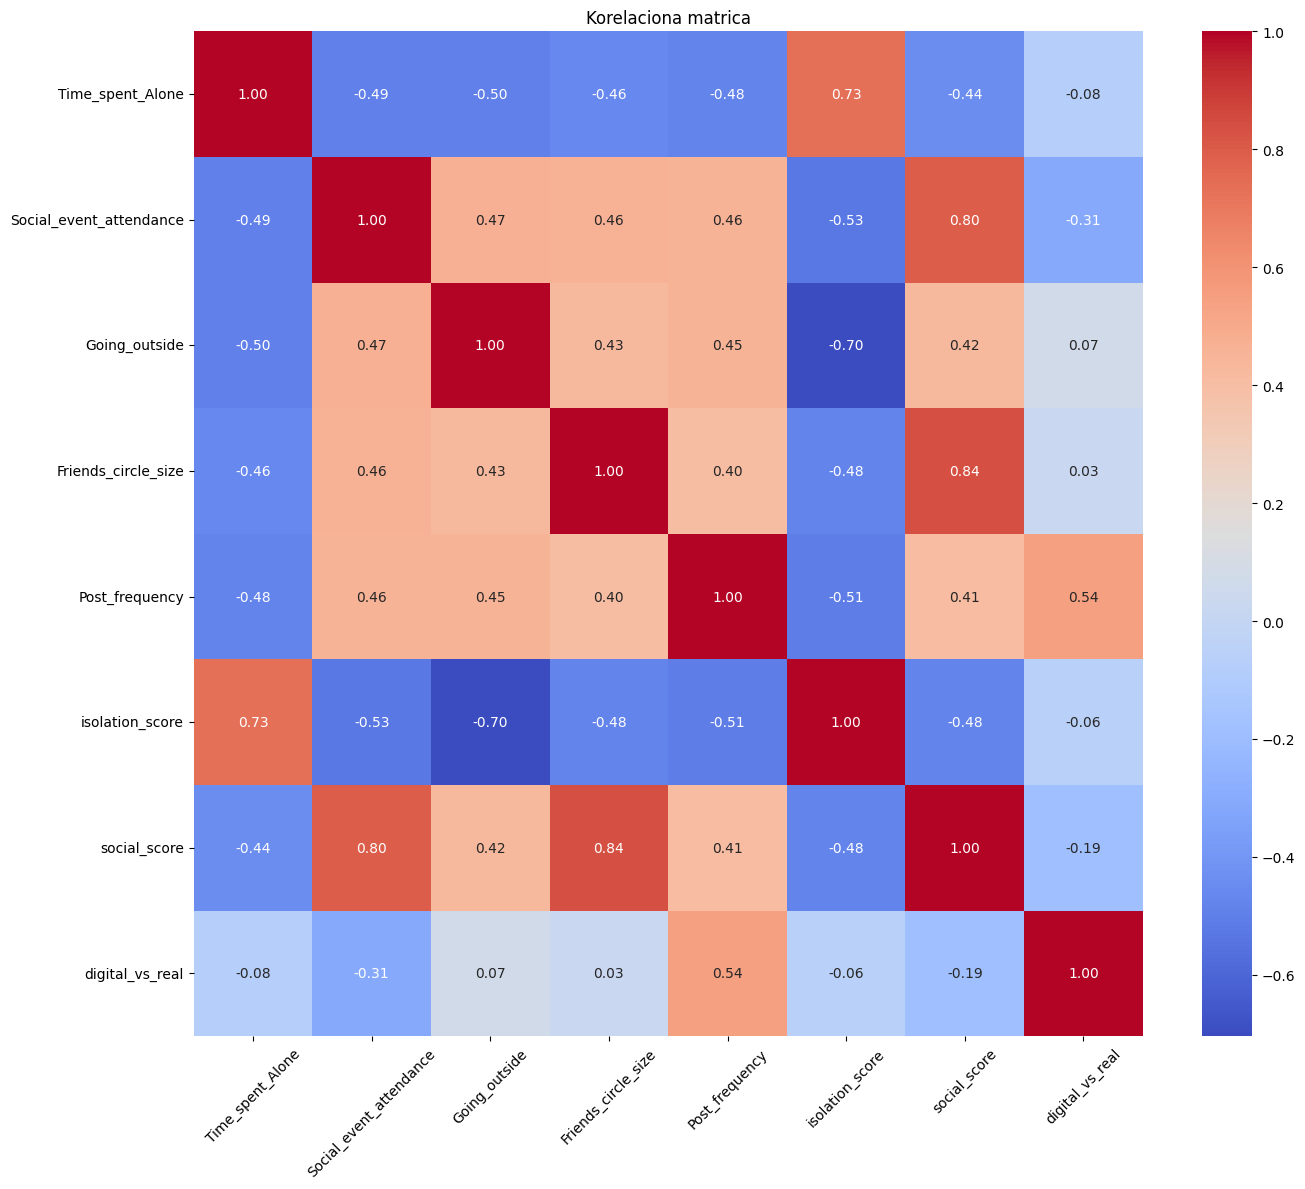

In [44]:
plt.figure(figsize=(14, 12))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Korelaciona matrica")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### 7.2 Iterativno uklanjanje korelisanih kolona

U ovoj sekciji primenjuje se iterativni proces uklanjanja veoma korelisanih kolona.

Postupak funkcioniše na sledeći način:

1. pronalazi se par kolona sa najvećom korelacijom,
2. računa se feature importance za obe kolone,
3. uklanja se kolona koja ima manju importance vrednost,
4. model se ponovo trenira,
5. ponovo se računa korelaciona matrica,
6. postupak se ponavlja dok više nema veoma korelisanih kolona.

Prag za jaku korelaciju postavljen je na: 0.8

što znači da se kolone sa korelacijom većom od 0.8 smatraju veoma povezanim.

Prilikom izbora kolone za uklanjanje koristi se Feature Importance analiza, jer:

- želimo da zadržimo korisnije informacije,
- uklanjamo manje značajne karakteristike,
- smanjujemo redundantnost bez velikog gubitka informacija.

Nakon svakog uklanjanja:

- prikazuje se nova heatmap,
- model se ponovo trenira,
- analiziraju se novi rezultati.

Cilj ovog procesa je:

- smanjenje redundantnih podataka,
- jednostavniji model,
- manji rizik od overfitting-a,
- bolje generalizovanje modela na nove podatke.

In [45]:
# prag za jaku korelaciju
corr_threshold = 0.8

X_train_iter = X_train_fe.copy()
X_test_iter = X_test_fe.copy()

removed_columns = []

iteration = 1


Iteracija 1
Najviše korelisan par: (Friends_circle_size, social_score) = 0.837
Zadržava se Friends_circle_size
Uklanja se social_score


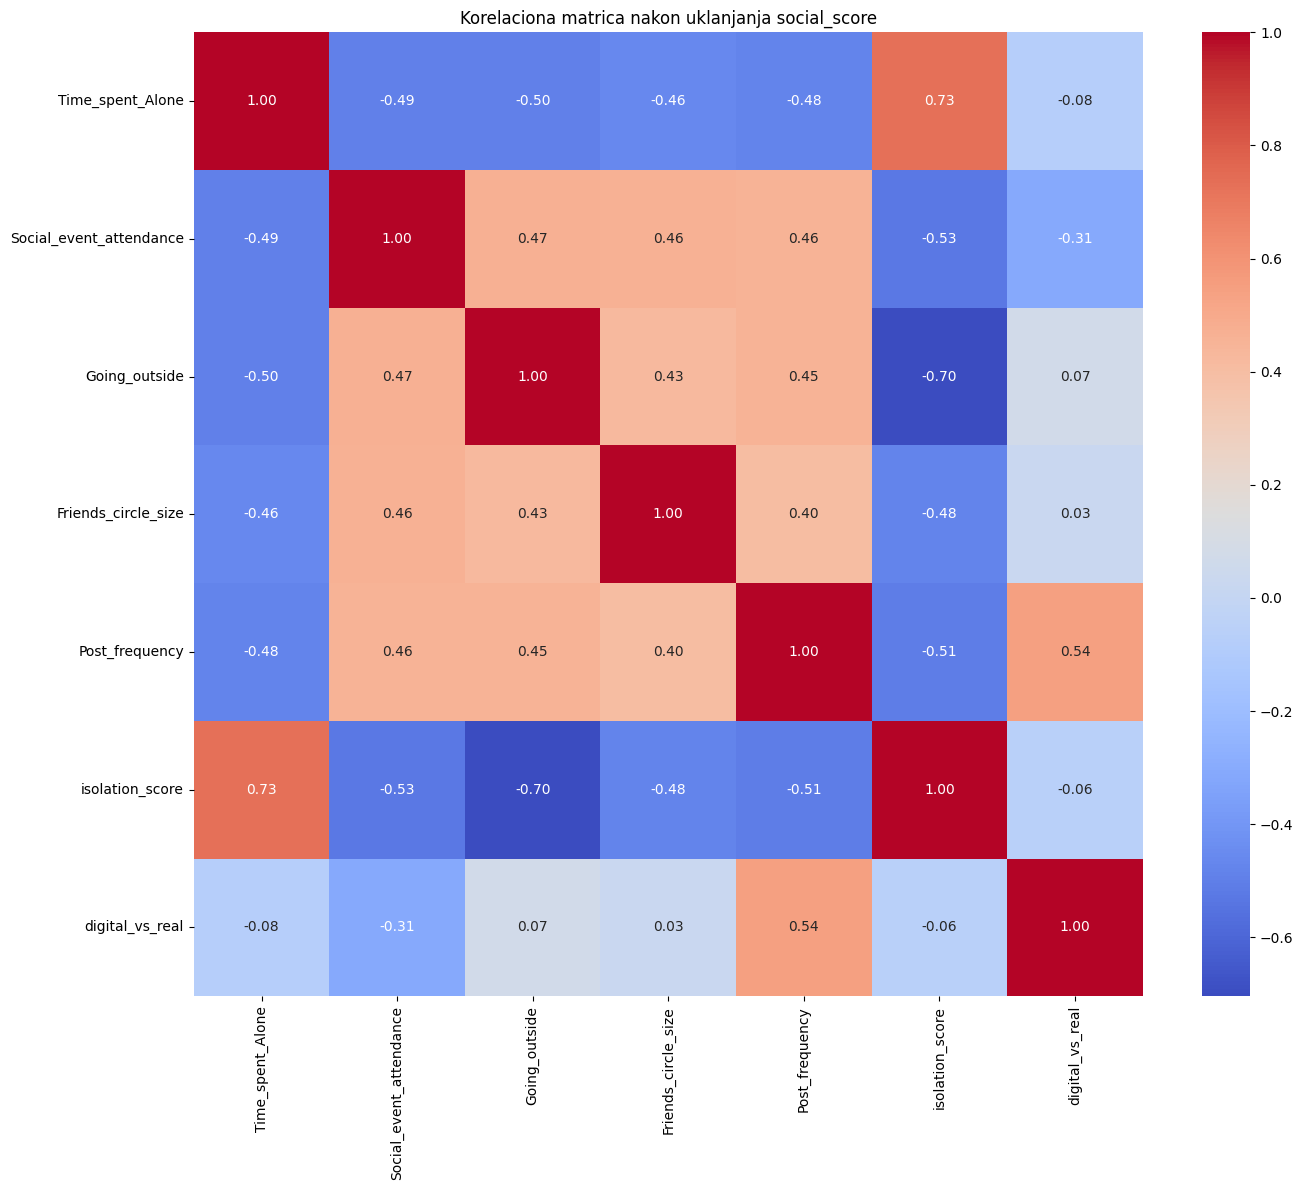

In [46]:
while True:

    # numeričke kolone
    numeric_cols_iter = (
        X_train_iter
        .select_dtypes(include=np.number)
        .columns
        .tolist()
    )

    # korelaciona matrica
    corr_iter = (
        X_train_iter[numeric_cols_iter]
        .corr()
        .abs()
    )

    # gornji trougao matrice
    upper_iter = corr_iter.where(
        np.triu(
            np.ones(corr_iter.shape),
            k=1
        ).astype(bool)
    )

    # maksimalna korelacija
    max_corr = upper_iter.max().max()

    # prekid ako nema velikih korelacija
    if pd.isna(max_corr) or max_corr <= corr_threshold:
        break

    # pronalazak najviše korelisanog para
    max_pair = np.where(upper_iter == max_corr)

    i, j = max_pair[0][0], max_pair[1][0]

    col1 = corr_iter.index[i]
    col2 = corr_iter.columns[j]

    print(
        f"\nIteracija {iteration}"
    )

    print(
        f"Najviše korelisan par:"
        f" ({col1}, {col2}) = {max_corr:.3f}"
    )

    # feature importance model
    categorical_cols_iter = (
        X_train_iter
        .select_dtypes(exclude=np.number)
        .columns
        .tolist()
    )

    preprocessor_iter = ColumnTransformer(
        transformers=[
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ),
                categorical_cols_iter
            )
        ],
        remainder="passthrough"
    )

    importance_model = Pipeline(
        steps=[
            ("preprocessor", preprocessor_iter),
            ("clf", ExtraTreesClassifier(random_state=42))
        ]
    )

    importance_model.fit(
        X_train_iter,
        y_train
    )

    current_importances = (
        get_feature_importance_df(
            importance_model
        )
    )

    # importance vrednosti
    imp1 = current_importances.get(col1, 0)
    imp2 = current_importances.get(col2, 0)

    # biranje kolone za uklanjanje
    if imp1 < imp2:

        drop_col = col1
        keep_col = col2

    else:

        drop_col = col2
        keep_col = col1

    print(
        f"Zadržava se {keep_col}"
    )

    print(
        f"Uklanja se {drop_col}"
    )

    # uklanjanje kolone
    X_train_iter = X_train_iter.drop(
        columns=[drop_col]
    )

    X_test_iter = X_test_iter.drop(
        columns=[drop_col]
    )

    removed_columns.append(drop_col)

    # nova heatmap
    plt.figure(figsize=(14, 12))

    sns.heatmap(
        X_train_iter
        .select_dtypes(include=np.number)
        .corr(),
        annot=True,
        fmt=".2f",
        cmap="coolwarm"
    )

    plt.title(
        f"Korelaciona matrica nakon uklanjanja {drop_col}"
    )

    plt.tight_layout()
    plt.show()

    iteration += 1

In [47]:
print(
    "\nUklonjene kolone:"
)

print(removed_columns)


Uklonjene kolone:
['social_score']


### 7.3 Finalni model

In [48]:
final_categorical_cols = (
    X_train_iter
    .select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

final_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            final_categorical_cols
        )
    ],
    remainder="passthrough"
)

final_pipeline = Pipeline(
    steps=[
        ("preprocessor", final_preprocessor),
        ("clf", ExtraTreesClassifier(random_state=42))
    ]
)

final_pipeline.fit(
    X_train_iter,
    y_train
)

final_metrics = compute_metrics(
    final_pipeline,
    X_test_iter,
    y_test
)

print("\nFinalni rezultati:")
print(final_metrics)


Finalni rezultati:
{'accuracy': 0.9538763493621197, 'precision': 0.9530301095294382, 'recall': 0.9538763493621197, 'f1': 0.9532278666652271}
